# AGENTS026 — Log Embedding (UC-8)
**BGE embeddings of structured log entries on GPU → semantic log search + anomaly clustering**

- Cell 1: Imports + log corpus builder
- Cell 2: Embed logs on GPU
- Cell 3: FAISS log index
- Cell 4: Semantic log search
- Cell 5: Log cluster visualisation
- Cell 6: GPU narrative from anomalous log cluster

In [1]:
# ── Cell 1: Imports + log corpus builder ─────────────────────────────────
import json, time, random
from pathlib import Path
from datetime import datetime, timezone, timedelta
import numpy as np
import faiss
import torch
from sentence_transformers import SentenceTransformer
from openai import OpenAI
import matplotlib.pyplot as plt

AUDIT_FILE    = Path("/workspace/shared/audit_log.jsonl")
LOG_INDEX     = Path("/workspace/shared/faiss_logs.index")
LOG_META      = Path("/workspace/shared/faiss_logs_meta.jsonl")
LOG_RESULTS   = Path("/workspace/shared/log_search_results.jsonl")
LOG_PCA_IMG   = Path("/workspace/shared/log_embedding_pca.png")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

llm = OpenAI(base_url="http://localhost:8000/v1", api_key="abc-123")
def ts(): return datetime.now(timezone.utc).isoformat()
def write_log(path, event):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a") as f: f.write(json.dumps(event, default=str) + "\n")

# Build synthetic log corpus (banking microservices)
LOG_TEMPLATES = [
    # Normal
    ("payments",  "INFO",  "Transaction processed: txn_id={} amount={} status=SUCCESS"),
    ("auth",      "INFO",  "JWT validated: user_id={} token_expiry={}s"),
    ("checkout",  "INFO",  "Order created: order_id={} items={} customer_id={}"),
    ("fraud",     "INFO",  "Risk score computed: txn_id={} score={} decision=ALLOW"),
    # Warnings
    ("payments",  "WARN",  "Payment gateway latency high: {} ms, retrying attempt {}/3"),
    ("auth",      "WARN",  "Token refresh rate elevated: {} requests/min, threshold=100"),
    ("checkout",  "WARN",  "Session cache near capacity: {}% used"),
    ("fraud",     "WARN",  "ML model batch size limit reached: {} items queued"),
    # Errors
    ("payments",  "ERROR", "Payment gateway timeout: txn_id={} elapsed={}ms circuit_breaker=OPEN"),
    ("auth",      "ERROR", "JWT signature invalid: user_id={} reason=KEY_MISMATCH"),
    ("checkout",  "ERROR", "Order failed: order_id={} reason=FRAUD_SCREEN_TIMEOUT"),
    ("fraud",     "ERROR", "Risk model exception: txn_id={} error=NullPointerException score=UNKNOWN"),
    # Critical
    ("payments",  "CRITICAL", "Payment processor unreachable: host={} consecutive_failures={}"),
    ("auth",      "CRITICAL", "Redis connection pool exhausted: pool_size={} waiting={}"),
    ("checkout",  "CRITICAL", "OOM error: service=checkout heap_used={}MB heap_max={}MB"),
    ("fraud",     "CRITICAL", "CPU saturation: utilization={}% throttling ML inference"),
]

def generate_logs(n=200):
    logs = []
    base_time = datetime.now(timezone.utc) - timedelta(hours=2)
    for i in range(n):
        svc, level, tmpl = random.choice(LOG_TEMPLATES)
        # Fill template placeholders with random values
        vals = [random.randint(1000,9999), random.randint(10,5000),
                random.randint(1,99), f"node-{random.randint(1,2)}"]
        try:
            msg = tmpl.format(*vals[:tmpl.count("{}")])
        except:
            msg = tmpl.replace("{}", str(random.randint(100,999)))
        log_time = base_time + timedelta(seconds=i*36 + random.randint(0,30))
        logs.append({
            "log_id":    f"LOG-{i+1:04d}",
            "timestamp": log_time.isoformat(),
            "service":   svc,
            "level":     level,
            "message":   msg,
            "text":      f"[{level}] {svc}: {msg}"
        })
    # Also load real audit log entries if present
    if AUDIT_FILE.exists():
        for line in AUDIT_FILE.read_text().strip().split("\n"):
            if not line.strip(): continue
            try:
                rec = json.loads(line)
                logs.append({
                    "log_id":    f"AUDIT-{rec.get('timestamp',ts())[-8:].replace(':','-')}",
                    "timestamp": rec.get("timestamp", ts()),
                    "service":   rec.get("service", "system"),
                    "level":     "AUDIT",
                    "message":   str(rec.get("event_type","")),
                    "text":      f"[AUDIT] {rec.get('event_type','')} service={rec.get('service','')} {json.dumps({k:v for k,v in rec.items() if k not in ('event_type','service','timestamp')})[:120]}"
                })
            except: pass
    return logs

LOG_CORPUS = generate_logs(200)
LOG_TEXTS  = [l["text"] for l in LOG_CORPUS]
print(f"✅ Log corpus: {len(LOG_CORPUS)} entries ({sum(1 for l in LOG_CORPUS if l['level']=='AUDIT')} audit, {sum(1 for l in LOG_CORPUS if l['level'] in ('ERROR','CRITICAL'))} errors/critical)")

Device: cuda
✅ Log corpus: 266 entries (66 audit, 97 errors/critical)


In [2]:
# ── Cell 2: Embed logs on GPU ─────────────────────────────────────────────
print(f"Loading BGE-large-en-v1.5 on {DEVICE}...")
embedder = SentenceTransformer("BAAI/bge-large-en-v1.5", device=DEVICE)
DIM = embedder.get_sentence_embedding_dimension()
print(f"Model ready — dim={DIM}")

print(f"\nEmbedding {len(LOG_TEXTS)} log entries on {DEVICE}...")
t0 = time.time()
LOG_EMBEDDINGS = embedder.encode(
    LOG_TEXTS, batch_size=64, show_progress_bar=True,
    normalize_embeddings=True, device=DEVICE
)
elapsed = time.time() - t0
print(f"✅ {len(LOG_EMBEDDINGS)} logs embedded in {elapsed:.2f}s ({len(LOG_EMBEDDINGS)/elapsed:.0f} logs/sec)")
print(f"   Shape: {LOG_EMBEDDINGS.shape}")

Loading BGE-large-en-v1.5 on cuda...
Model ready — dim=1024

Embedding 266 log entries on cuda...


/tmp/ipykernel_10224/518616095.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  DIM = embedder.get_sentence_embedding_dimension()


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

✅ 266 logs embedded in 17.06s (16 logs/sec)
   Shape: (266, 1024)


In [3]:
# ── Cell 3: FAISS log index ───────────────────────────────────────────────
index = faiss.IndexFlatIP(DIM)
index.add(LOG_EMBEDDINGS.astype(np.float32))
faiss.write_index(index, str(LOG_INDEX))

with open(LOG_META, "w") as f:
    for i, log in enumerate(LOG_CORPUS):
        f.write(json.dumps({"faiss_id": i, **log}, default=str) + "\n")

print(f"✅ FAISS log index: {index.ntotal} vectors → {LOG_INDEX}")
print(f"   Metadata        → {LOG_META}")

✅ FAISS log index: 266 vectors → /workspace/shared/faiss_logs.index
   Metadata        → /workspace/shared/faiss_logs_meta.jsonl


In [4]:
# ── Cell 4: Semantic log search ───────────────────────────────────────────

def search_logs(query, top_k=5):
    idx  = faiss.read_index(str(LOG_INDEX))
    meta = [json.loads(l) for l in LOG_META.read_text().strip().split("\n") if l.strip()]
    q_emb = embedder.encode(
        [f"Represent this log for retrieval: {query}"],
        normalize_embeddings=True, device=DEVICE
    ).astype(np.float32)
    scores, ids = idx.search(q_emb, top_k)
    results = []
    for score, fid in zip(scores[0], ids[0]):
        if fid == -1: continue
        entry = meta[fid].copy()
        entry["similarity"] = float(score)
        results.append(entry)
    return results

# Demo searches
DEMO_QUERIES = [
    "payment gateway timeout circuit breaker",
    "JWT token authentication failure",
    "memory heap out of memory OOM",
    "fraud ML model exception error",
    "CPU utilization saturation",
]

all_results = []
for query in DEMO_QUERIES:
    results = search_logs(query, top_k=3)
    print(f"\n🔍 Query: '{query}'")
    for r in results:
        icon = {"CRITICAL":"💀","ERROR":"🔴","WARN":"🟡","INFO":"🟢","AUDIT":"📋"}.get(r["level"],"⚪")
        print(f"   {icon} sim={r['similarity']:.3f} | {r['service']:10s} | {r['level']:8s} | {r['message'][:80]}")
    all_results.extend(results)

write_log(LOG_RESULTS, {"event_type":"LOG_SEARCH_BATCH", "queries": DEMO_QUERIES,
                        "total_results": len(all_results), "timestamp": ts()})
print(f"\n✅ Log search demo complete")


🔍 Query: 'payment gateway timeout circuit breaker'
   🔴 sim=0.866 | payments   | ERROR    | Payment gateway timeout: txn_id=6541 elapsed=2198ms circuit_breaker=OPEN
   🔴 sim=0.865 | payments   | ERROR    | Payment gateway timeout: txn_id=3884 elapsed=2748ms circuit_breaker=OPEN
   🔴 sim=0.865 | payments   | ERROR    | Payment gateway timeout: txn_id=9683 elapsed=512ms circuit_breaker=OPEN

🔍 Query: 'JWT token authentication failure'
   🟢 sim=0.728 | auth       | INFO     | JWT validated: user_id=6888 token_expiry=207s
   🟢 sim=0.727 | auth       | INFO     | JWT validated: user_id=1077 token_expiry=3396s
   🟢 sim=0.723 | auth       | INFO     | JWT validated: user_id=8738 token_expiry=3052s

🔍 Query: 'memory heap out of memory OOM'
   💀 sim=0.728 | checkout   | CRITICAL | OOM error: service=checkout heap_used=6252MB heap_max=1560MB
   💀 sim=0.727 | checkout   | CRITICAL | OOM error: service=checkout heap_used=4188MB heap_max=4567MB
   💀 sim=0.726 | checkout   | CRITICAL | OOM error: s

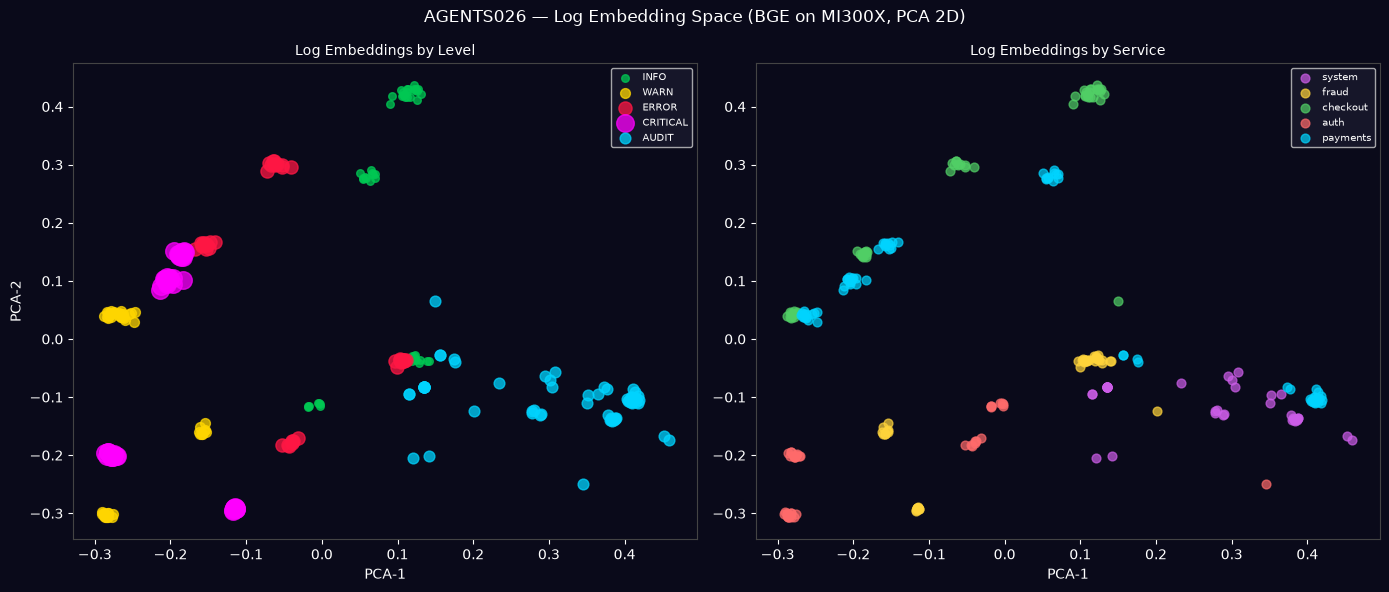

✅ Saved to /workspace/shared/log_embedding_pca.png
   PC1 variance: 15.9%  PC2: 12.4%


In [5]:
# ── Cell 5: Log cluster visualisation ────────────────────────────────────
from sklearn.decomposition import PCA
from collections import Counter

pca   = PCA(n_components=2)
emb2d = pca.fit_transform(LOG_EMBEDDINGS)

LEVEL_COLORS = {"INFO":"#00c853","WARN":"#ffd600",
                "ERROR":"#ff1744","CRITICAL":"#ff00ff","AUDIT":"#00d4ff"}
LEVEL_SIZES  = {"INFO":30,"WARN":50,"ERROR":90,"CRITICAL":160,"AUDIT":60}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("#0a0a1a")

# Left: coloured by log level
ax = axes[0]; ax.set_facecolor("#0a0a1a"); ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#444")
for level in ["INFO","WARN","ERROR","CRITICAL","AUDIT"]:
    mask = np.array([l["level"]==level for l in LOG_CORPUS])
    if mask.any():
        ax.scatter(emb2d[mask,0], emb2d[mask,1],
                   c=LEVEL_COLORS[level], s=LEVEL_SIZES[level],
                   label=level, alpha=0.75, zorder=5)
ax.set_title("Log Embeddings by Level", color="white", fontsize=10)
ax.set_xlabel("PCA-1", color="white"); ax.set_ylabel("PCA-2", color="white")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=7)

# Right: coloured by service
SVC_COLORS = {"payments":"#00d4ff","auth":"#ff6b6b","checkout":"#51cf66",
              "fraud":"#ffd43b","system":"#cc5de8"}
ax2 = axes[1]; ax2.set_facecolor("#0a0a1a"); ax2.tick_params(colors="white")
for spine in ax2.spines.values(): spine.set_edgecolor("#444")
for svc in set(l["service"] for l in LOG_CORPUS):
    mask = np.array([l["service"]==svc for l in LOG_CORPUS])
    if mask.any():
        ax2.scatter(emb2d[mask,0], emb2d[mask,1],
                    c=SVC_COLORS.get(svc,"#aaa"), s=40, label=svc, alpha=0.7, zorder=5)
ax2.set_title("Log Embeddings by Service", color="white", fontsize=10)
ax2.set_xlabel("PCA-1", color="white")
ax2.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=7)

plt.suptitle("AGENTS026 — Log Embedding Space (BGE on MI300X, PCA 2D)", color="white", fontsize=12)
plt.tight_layout()
plt.savefig(str(LOG_PCA_IMG), dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved to {LOG_PCA_IMG}")
print(f"   PC1 variance: {pca.explained_variance_ratio_[0]:.1%}  PC2: {pca.explained_variance_ratio_[1]:.1%}")

In [6]:
# ── Cell 6: GPU narrative from anomalous log cluster ─────────────────────

# Find all ERROR/CRITICAL logs
critical_logs = [l for l in LOG_CORPUS if l["level"] in ("ERROR","CRITICAL")]
print(f"Anomalous logs (ERROR+CRITICAL): {len(critical_logs)}")

log_block = "\n".join(
    f"[{l['timestamp'][:19]}] [{l['level']:8s}] {l['service']:10s}: {l['message']}"
    for l in critical_logs[:15]   # first 15 for context window
)

prompt = f"""You are a banking SRE analysing a cluster of anomalous log entries.
These logs were retrieved by semantic similarity from a BGE embedding index on AMD MI300X.

ANOMALOUS LOG CLUSTER:
{log_block}

Write a concise incident narrative (3-4 sentences):
1. What failure pattern do these logs reveal?
2. Which service is the most likely origin?
3. What is the recommended immediate action?"""

print("\n🧠 GPU narrative from anomalous log cluster...")
t0 = time.time()
resp = llm.chat.completions.create(
    model="Qwen3-30B-A3B",
    messages=[{"role": "user", "content": prompt}],
    temperature=0.2, max_tokens=200,
    extra_body={"chat_template_kwargs": {"enable_thinking": False}}
)
elapsed = time.time() - t0
narrative = resp.choices[0].message.content.strip()

print(f"\n{'='*60}")
print(narrative)
print(f"{'='*60}")
print(f"\n⏱️  GPU response time: {elapsed:.2f}s")

write_log(AUDIT_FILE, {
    "event_type":     "LOG_EMBEDDING_NARRATIVE",
    "anomalous_count": len(critical_logs),
    "narrative":      narrative,
    "gpu_time_secs":  round(elapsed, 2),
    "timestamp":      ts()
})
print("\n✅ Narrative saved to audit log")

Anomalous logs (ERROR+CRITICAL): 97

🧠 GPU narrative from anomalous log cluster...

1. The logs reveal a failure pattern characterized by repeated payment processor unreachability, memory exhaustion in the checkout service, and fraud system performance degradation due to CPU saturation, leading to transaction timeouts and order failures.  
2. The payments service appears to be the most likely origin of the incident, as it is repeatedly logged with critical errors related to processor unavailability and gateway timeouts.  
3. The recommended immediate action is to investigate and restore the payment processor connectivity, check for any ongoing resource exhaustion in the checkout service, and ensure the fraud system is not causing cascading performance issues.

⏱️  GPU response time: 1.15s

✅ Narrative saved to audit log
